# Face Model Lab: Training & Qualitätsanalyse

Dieses Notebook steuert die eigenständigen Skripte im Lab. Die Zellen sind bewusst als kleine, reproduzierbare Experimente aufgebaut: trainieren, evaluieren, Ergebnisdateien lesen und grafisch vergleichen.

In [1]:
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd().parent / "matplotlib_cache"))
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import torch

LAB = Path.cwd()
ROOT = LAB.parent
RESULTS = ROOT / "model_results"
MODELS = ROOT / "trained_models"
PYTHON = sys.executable

print("Lab:", LAB)
print("Python:", PYTHON)
print("Torch:", torch.__version__)
print("ROCm/HIP:", getattr(torch.version, "hip", None))
print("GPU sichtbar:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Lab: /home/clemi/projekte/MIM/face_model_lab
Python: /home/clemi/.venvs/MIM/bin/python
Torch: 2.9.1+rocm6.4
ROCm/HIP: 6.4.43484-123eb5128
GPU sichtbar: True
GPU: AMD Radeon PRO W7800 48GB


## Laufgröße konfigurieren

Ändere hier die Trainingsgröße. `smoke` prüft nur, ob der Ablauf funktioniert. `medium` ist der nächste sinnvolle Test. `full` nutzt den kompletten Datensatz und dauert entsprechend lange. Für echte Vergleiche immer nur eine Variable auf einmal ändern: erst Bilder, dann Epochen, dann Bildgröße.

In [2]:
RUN_PRESET = "smoke"  # "smoke", "medium" oder "full"

PRESETS = {
    "smoke": {
        "epochs": 1,
        "batch": 2,
        "imgsz": 640,
        "ultra_train_limit": 20,
        "ultra_val_limit": 8,
        "torchvision_reduction": 2000,
        "eval_limit": 8,
    },
    "medium": {
        "epochs": 5,
        "batch": 2,
        "imgsz": 640,
        "ultra_train_limit": 1000,
        "ultra_val_limit": 200,
        "torchvision_reduction": 50,
        "eval_limit": 200,
    },
    "full": {
        "epochs": 20,
        "batch": 2,
        "imgsz": 768,
        "ultra_train_limit": None,
        "ultra_val_limit": None,
        "torchvision_reduction": 1,
        "eval_limit": 1000,
    },
}

cfg = PRESETS[RUN_PRESET].copy()

# Optional manuelle Overrides, z.B.:
# cfg["epochs"] = 5
# cfg["ultra_train_limit"] = 5000
# cfg["imgsz"] = 960
# cfg["batch"] = 2

TORCHVISION_KINDS = ["retinanet", "fasterrcnn"]  # weitere Optionen: "fcos"
SAVE_EVERY = 1  # speichert pro Epoche einen nutzbaren Zwischenstand
INCLUDE_INSIGHTFACE_BASELINE = False
INCLUDE_MTCNN_BASELINE = False
SCORE_THRESHOLDS = [0.25, 0.5, 0.7]  # Precision/Recall-Sweep für Torchvision-Modelle

print("Preset:", RUN_PRESET)
for key, value in cfg.items():
    print(f"{key}: {value}")
print("torchvision models:", TORCHVISION_KINDS)
print("save_every:", SAVE_EVERY)
print("include_insightface:", INCLUDE_INSIGHTFACE_BASELINE)
print("include_mtcnn:", INCLUDE_MTCNN_BASELINE)
print("score_thresholds:", SCORE_THRESHOLDS)


Preset: smoke
epochs: 1
batch: 2
imgsz: 640
ultra_train_limit: 20
ultra_val_limit: 8
torchvision_reduction: 2000
eval_limit: 8
torchvision models: ['retinanet', 'fasterrcnn']
save_every: 1
include_insightface: False
include_mtcnn: False
score_thresholds: [0.25, 0.5, 0.7]


## Trainingsdaten mit Validierungsdaten vergleichen

Dieser Vergleich läuft immer vor Training/Evaluation. So siehst du, ob Train und Validation ähnlich verteilt sind oder ob Validation deutlich schwerer ist.

split,images,images_with_faces,faces,mean_faces_per_image,max_faces_per_image
train,12880,12876,159393,12.38,1968
val,3226,3222,39697,12.31,709


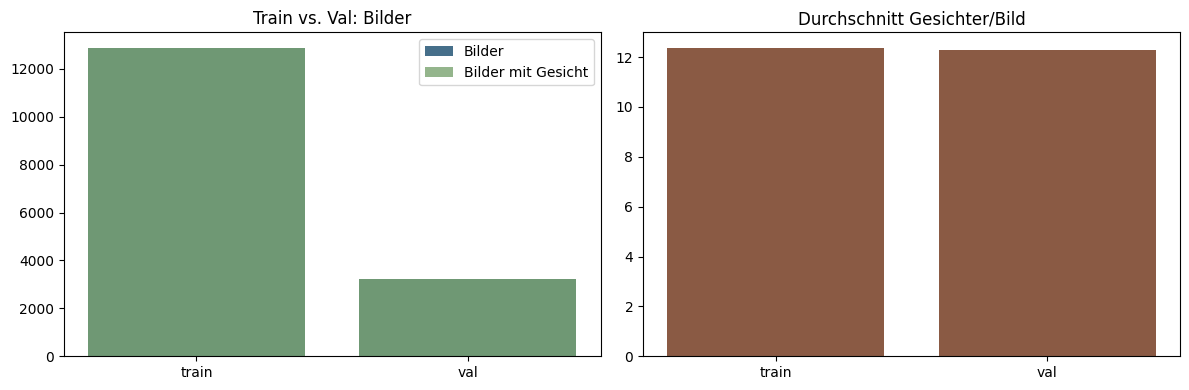

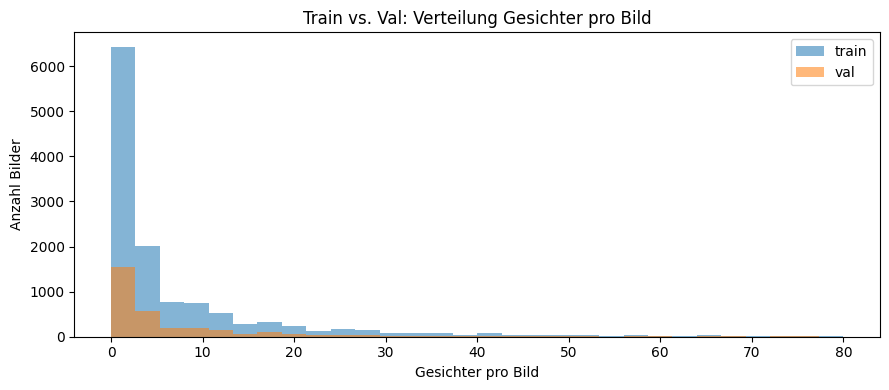

In [3]:
from step00_common import compare_train_val, parse_wider_face_gt, wider_paths

dataset_rows = compare_train_val()
print("split,images,images_with_faces,faces,mean_faces_per_image,max_faces_per_image")
for row in dataset_rows:
    print(f"{row['split']},{row['images']},{row['images_with_faces']},{row['faces']},{row['faces_per_image_mean']:.2f},{row['faces_per_image_max']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
splits = [row["split"] for row in dataset_rows]
axes[0].bar(splits, [row["images"] for row in dataset_rows], label="Bilder", color="#466f8a")
axes[0].bar(splits, [row["images_with_faces"] for row in dataset_rows], label="Bilder mit Gesicht", color="#7aa36f", alpha=0.8)
axes[0].set_title("Train vs. Val: Bilder")
axes[0].legend()

axes[1].bar(splits, [row["faces_per_image_mean"] for row in dataset_rows], color="#8a5a44")
axes[1].set_title("Durchschnitt Gesichter/Bild")
plt.tight_layout()
plt.show()

# Verteilung als Histogramm: Anzahl Gesichter pro Bild
fig, ax = plt.subplots(figsize=(9, 4))
for split in ["train", "val"]:
    _, gt_file = wider_paths(split)
    counts = [len(faces) for faces in parse_wider_face_gt(gt_file).values()]
    ax.hist(counts, bins=30, alpha=0.55, label=split, range=(0, min(max(counts), 80)))
ax.set_title("Train vs. Val: Verteilung Gesichter pro Bild")
ax.set_xlabel("Gesichter pro Bild")
ax.set_ylabel("Anzahl Bilder")
ax.legend()
plt.tight_layout()
plt.show()


## Experiment-Plan

Empfohlenes Vorgehen:

1. YOLO-Finetuning als starke Video-Baseline.
2. RT-DETR als wichtigste Nicht-YOLO-Alternative.
3. RetinaNet und FCOS als klassische One-Stage-Baselines.
4. Faster R-CNN als Two-Stage-Qualitätsbaseline.
5. Alle Modelle auf demselben Validierungs-Sample vergleichen.

In [4]:
def run_cmd(args):
    print("$", " ".join(map(str, args)))
    result = subprocess.run(args, cwd=ROOT, text=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}")

def latest_eval_csv():
    files = sorted(RESULTS.glob("evaluation_*.csv"), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError("Noch keine evaluation_*.csv in model_results gefunden.")
    return files[-1]


## YOLO trainieren

YOLO ist die wahrscheinlich beste praktische Video-Basis. Für größere Läufe oben `RUN_PRESET` auf `medium` oder `full` stellen. Wenn du eigene Werte willst, überschreibe im Konfigurationsblock z.B. `cfg["epochs"] = 5` oder `cfg["ultra_train_limit"] = 5000`.


In [5]:
weights_path = ROOT / "face_yolov8m.pt"
if not weights_path.exists():
    print(f"Überspringe Training: {weights_path} ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.")
else:
    args = [
        PYTHON, "face_model_lab/step02_train_ultralytics_detector.py",
        "--family", "yolo",
        "--base", str(weights_path),
        "--epochs", str(cfg["epochs"]),
        "--batch", str(cfg["batch"]),
        "--imgsz", str(cfg["imgsz"]),
    ]
    if cfg["ultra_train_limit"] is not None:
        args += ["--train-limit", str(cfg["ultra_train_limit"])]
    if cfg["ultra_val_limit"] is not None:
        args += ["--val-limit", str(cfg["ultra_val_limit"])]
    run_cmd(args)


Überspringe Training: /home/clemi/projekte/MIM/face_yolov8m.pt ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.


## RT-DETR trainieren

RT-DETR ist der wichtigste Nicht-YOLO-Herausforderer. Er verwendet dieselben `cfg`-Werte wie YOLO, damit beide Verfahren fair vergleichbar bleiben.


In [6]:
weights_path = ROOT / "rtdetr-l.pt"
if not weights_path.exists():
    print(f"Überspringe Training: {weights_path} ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.")
else:
    args = [
        PYTHON, "face_model_lab/step02_train_ultralytics_detector.py",
        "--family", "rtdetr",
        "--base", str(weights_path),
        "--epochs", str(cfg["epochs"]),
        "--batch", str(cfg["batch"]),
        "--imgsz", str(cfg["imgsz"]),
    ]
    if cfg["ultra_train_limit"] is not None:
        args += ["--train-limit", str(cfg["ultra_train_limit"])]
    if cfg["ultra_val_limit"] is not None:
        args += ["--val-limit", str(cfg["ultra_val_limit"])]
    run_cmd(args)


Überspringe Training: /home/clemi/projekte/MIM/rtdetr-l.pt ist lokal nicht vorhanden. Für einen echten Lauf Gewichtedatei ablegen oder Internet-Download erlauben.


## Torchvision-Baselines trainieren

RetinaNet nutzt Focal Loss und ist interessant bei vielen Negativbeispielen. Faster R-CNN/RCNN ist die klassische Two-Stage-Qualitätsbaseline und bleibt wichtig, auch wenn sie für Video meist langsamer ist. FCOS ist anchor-free und kann über `TORCHVISION_KINDS` ergänzt werden.


In [7]:
# kind kann sein: retinanet, fasterrcnn, fcos
# Faster R-CNN/RCNN ist hier bewusst enthalten, damit der klassische Two-Stage-Vergleich nicht fehlt.
for kind in TORCHVISION_KINDS:
    run_cmd([
        PYTHON, "face_model_lab/step03_train_torchvision_detector.py",
        "--kind", kind,
        "--epochs", str(cfg["epochs"]),
        "--batch", str(cfg["batch"]),
        "--reduction", str(cfg["torchvision_reduction"]),
        "--save-every", str(SAVE_EVERY),
    ])


$ /home/clemi/.venvs/MIM/bin/python face_model_lab/step03_train_torchvision_detector.py --kind retinanet --epochs 1 --batch 2 --reduction 2000 --save-every 1


Using ROCm device: AMD Radeon PRO W7800 48GB
loading annotations into memory...


Done (t=0.23s)
creating index...
index created!


retinanet epoch 1/1:   0%|          | 0/4 [00:00<?, ?it/s]

retinanet epoch 1/1:  25%|██▌       | 1/4 [00:03<00:11,  3.68s/it, loss=1.9341, alloc=0.5G, res=0.7G, free=13.5G, total=48G]

...

fasterrcnn epoch 1/1:  75%|███████▌  | 3/4 [00:04<00:01,  1.29s/it, loss=0.2436, alloc=0.8G, res=1.2G, free=33.4G, total=48G]

fasterrcnn epoch 1/1: 100%|██████████| 4/4 [00:05<00:00,  1.32s/it, loss=0.6494, alloc=0.7G, res=1.0G, free=33.6G, total=48G]


epoch=1 mean_loss=0.9779


checkpoint saved /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
history updated /home/clemi/projekte/MIM/model_results/training_history_fasterrcnn_resnet50_fpn_rocm_bs2_ep1_20260614_215637.csv


saved /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth


## Modelle evaluieren

Trage hier die Modelle ein, die verglichen werden sollen. `.pt` wird als Ultralytics-Modell behandelt, `.pth` als Torchvision-Modell; der Typ wird aus dem Dateinamen abgeleitet.

In [8]:
models = [
    MODELS / "fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth",
    ROOT / "face_yolov8m.pt",
]

models += sorted(MODELS.glob("yolo*_bs*_ep*.pt"))
models += sorted(MODELS.glob("rtdetr*_bs*_ep*.pt"))
models += sorted(MODELS.glob("retinanet*_bs*_ep*.pth"))
models += sorted(MODELS.glob("fcos*_bs*_ep*.pth"))

seen = set()
existing = []
for model in models:
    model = model.resolve()
    if model.exists() and model not in seen:
        existing.append(model)
        seen.add(model)

args = [
    PYTHON, "face_model_lab/step06_evaluate_models.py",
    "--limit", str(cfg["eval_limit"]),
    "--imgsz", str(cfg["imgsz"]),
]
if SCORE_THRESHOLDS:
    args += ["--score-thresholds", *map(str, SCORE_THRESHOLDS)]
if INCLUDE_INSIGHTFACE_BASELINE:
    args += ["--include-insightface"]
if INCLUDE_MTCNN_BASELINE:
    args += ["--include-mtcnn"]

if existing:
    print("Lokale Modelle:")
    for model in existing:
        print("-", model)
    args += ["--models", *map(str, existing)]
else:
    print("Keine lokal trainierten Modelle gefunden.")
    print("Achtung: Evaluation nutzt als Fallback ein COCO-pretrained Faster R-CNN, nicht face-finetuned.")

run_cmd(args)


Lokale Modelle:
- /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
- /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth
$ /home/clemi/.venvs/MIM/bin/python face_model_lab/step06_evaluate_models.py --limit 8 --imgsz 640 --score-thresholds 0.25 0.5 0.7 --models /home/clemi/projekte/MIM/trained_models/fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth /home/clemi/projekte/MIM/trained_models/retinanet_resnet50_fpn_rocm_bs2_ep1.pth


Train-vs-Val dataset comparison:
  train: images=12880, faces=159393, mean_faces/image=12.38, max_faces/image=1968
  val: images=3226, faces=39697, mean_faces/image=12.31, max_faces/image=709


eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:   0%|          | 0/8 [00:00<?, ?it/s]

eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:  25%|██▌       | 2/8 [00:00<00:01,  3.18it/s]

eval fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth:  50%|█████     | 4/8 [00:00<00:00,  5.57it/s]

...

eval retinanet_resnet50_fpn_rocm_bs2_ep1.pth: 100%|██████████| 8/8 [00:00<00:00, 10.38it/s]


threshold sweep retinanet_resnet50_fpn_rocm_bs2_ep1.pth:  25%|██▌       | 2/8 [00:00<00:00, 11.54it/s]

threshold sweep retinanet_resnet50_fpn_rocm_bs2_ep1.pth:  75%|███████▌  | 6/8 [00:00<00:00, 12.08it/s]

threshold sweep retinanet_resnet50_fpn_rocm_bs2_ep1.pth: 100%|██████████| 8/8 [00:00<00:00, 12.00it/s]


wrote /home/clemi/projekte/MIM/model_results/evaluation_20260614_215701.csv
wrote /home/clemi/projekte/MIM/model_results/evaluation_20260614_215701.json
fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth: detection_accuracy_recall=0.000, ms/image=184.8
  Faster R-CNN: Solide Two-Stage-Qualitätsbaseline; gute Lokalisierung und interpretierbares Training.
  Achtung: Für Video eher langsam und VRAM/CPU-overhead-intensiv.
retinanet_resnet50_fpn_rocm_bs2_ep1.pth: detection_accuracy_recall=0.000, ms/image=96.3
  RetinaNet: One-Stage-Detector mit Focal Loss; interessant bei vielen einfachen Negativen und kleinen Objekten.
  Achtung: Meist langsamer/umständlicher als YOLO in der Video-Pipeline.


## Ergebnisse laden und visualisieren

Lade /home/clemi/projekte/MIM/model_results/evaluation_20260614_215701.csv
model,recall,true_faces,detected_faces,ms_per_image
fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth,0.000,387,0,184.8
retinanet_resnet50_fpn_rocm_bs2_ep1.pth,0.000,387,0,96.3


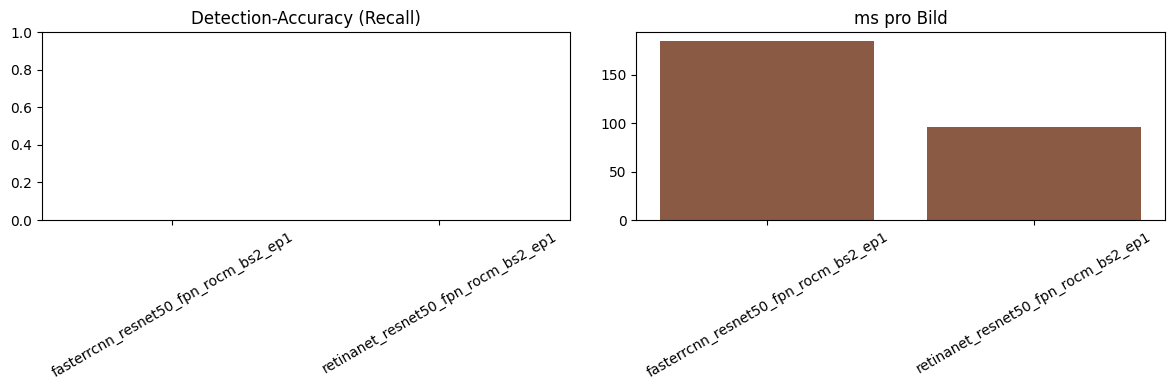

In [9]:
import csv

csv_path = latest_eval_csv()
print("Lade", csv_path)
with csv_path.open(newline="", encoding="utf-8") as fh:
    rows = list(csv.DictReader(fh))

for row in rows:
    row["recall"] = float(row["recall"])
    row["ms_per_image"] = float(row["ms_per_image"])
    row["true_faces"] = int(row["true_faces"])
    row["detected_faces"] = int(row["detected_faces"])

print("model,recall,true_faces,detected_faces,ms_per_image")
for row in rows:
    print(f"{row['model']},{row['recall']:.3f},{row['true_faces']},{row['detected_faces']},{row['ms_per_image']:.1f}")

labels = [Path(row["model"]).stem for row in rows]
recalls = [row["recall"] for row in rows]
speeds = [row["ms_per_image"] for row in rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, recalls, color="#2f6f9f")
axes[0].set_title("Detection-Accuracy (Recall)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, speeds, color="#8a5a44")
axes[1].set_title("ms pro Bild")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Loss und Detection-Accuracy über Epochen

Diese Grafik kombiniert Trainings-Loss aus `training_history_*.csv` mit Recall/Detection-Accuracy aus der neuesten Evaluation. Sie wird aussagekräftiger, sobald mehrere `*_epN.*` Checkpoints evaluiert wurden.


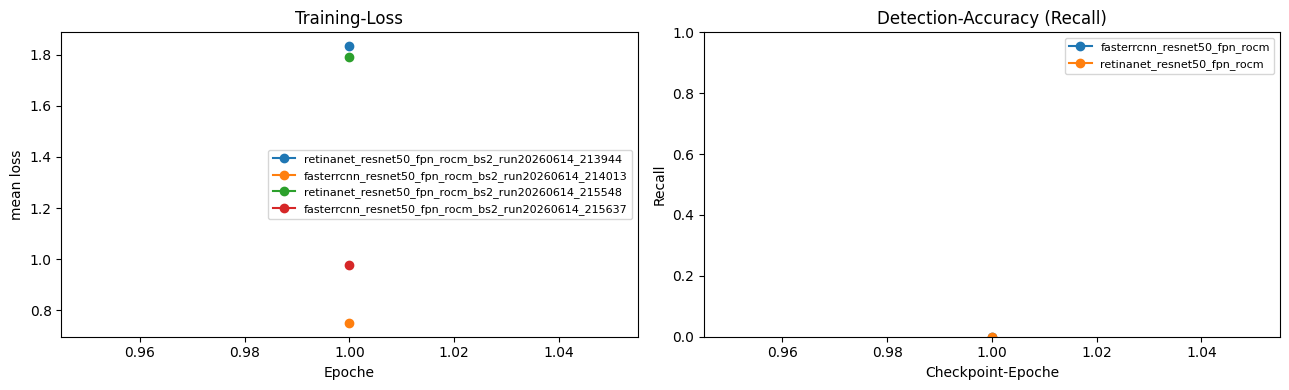

In [10]:
import re
from collections import defaultdict

history_files = sorted(RESULTS.glob("training_history_*.csv"), key=lambda p: p.stat().st_mtime)
eval_csv = latest_eval_csv()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if history_files:
    runs = []
    for history_path in history_files[-8:]:
        with history_path.open(newline="", encoding="utf-8") as fh:
            rows_hist = list(csv.DictReader(fh))
        if not rows_hist:
            continue
        label = f"{rows_hist[-1]['model']}_bs{rows_hist[-1]['batch']}_run{history_path.stem[-15:]}"
        epochs = [int(row["epoch"]) for row in rows_hist]
        losses = [float(row["mean_loss"]) for row in rows_hist]
        runs.append((label, epochs, losses))
    for label, epochs, losses in runs:
        axes[0].plot(epochs, losses, marker="o", label=label)
    axes[0].set_title("Training-Loss")
    axes[0].set_xlabel("Epoche")
    axes[0].set_ylabel("mean loss")
    if runs:
        axes[0].legend(fontsize=8)
else:
    axes[0].text(0.5, 0.5, "Noch keine training_history_*.csv gefunden", ha="center", va="center")
    axes[0].set_axis_off()

with eval_csv.open(newline="", encoding="utf-8") as fh:
    eval_rows = list(csv.DictReader(fh))

by_model = defaultdict(list)
for row in eval_rows:
    model_name = row["model"]
    match = re.search(r"_ep(\d+)", model_name)
    if not match:
        continue
    epoch = int(match.group(1))
    family = re.sub(r"_bs\d+_ep\d+.*$", "", Path(model_name).stem)
    by_model[family].append((epoch, float(row["recall"])))

if by_model:
    for family, points in sorted(by_model.items()):
        points = sorted(points)
        axes[1].plot([p[0] for p in points], [p[1] for p in points], marker="o", label=family)
    axes[1].set_title("Detection-Accuracy (Recall)")
    axes[1].set_xlabel("Checkpoint-Epoche")
    axes[1].set_ylabel("Recall")
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=8)
else:
    axes[1].text(0.5, 0.5, "Evaluiere mehrere *_epN.* Checkpoints\nfür eine Recall-Kurve", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## Score-Threshold-Sweep

Aus `Zusammenfassung` übernommen: Precision/Recall wird für mehrere Score-Schwellen geplottet. Das hilft bei der Wahl von `conf`, vor allem wenn verpasste Gesichter schlimmer sind als wenige False Positives.

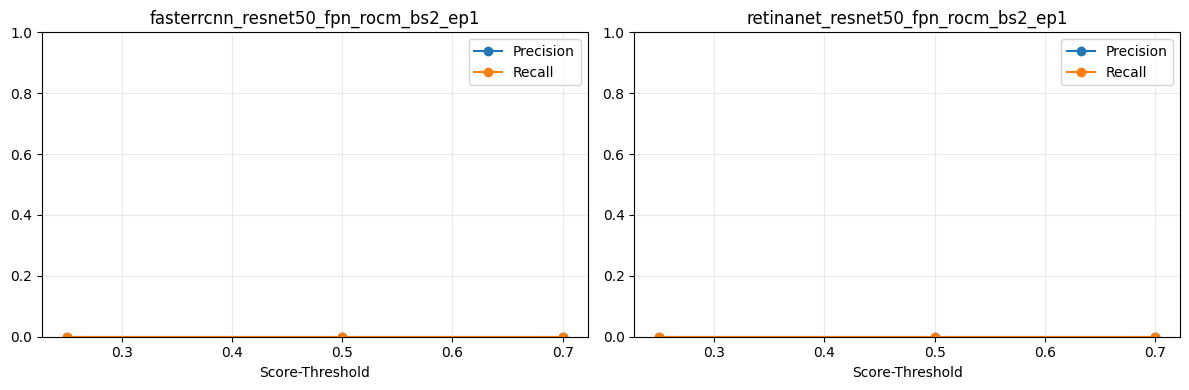

In [11]:
json_files = sorted(RESULTS.glob("evaluation_*.json"), key=lambda p: p.stat().st_mtime)
if not json_files:
    raise FileNotFoundError("Noch keine evaluation_*.json gefunden.")
payload = json.loads(json_files[-1].read_text(encoding="utf-8"))
sweeps = payload.get("threshold_sweeps", [])

if sweeps:
    by_model = {}
    for row in sweeps:
        by_model.setdefault(row["model"], []).append(row)
    fig, axes = plt.subplots(1, len(by_model), figsize=(6 * len(by_model), 4), squeeze=False)
    for ax, (model_name, rows_sweep) in zip(axes[0], by_model.items()):
        rows_sweep = sorted(rows_sweep, key=lambda r: r["score_threshold"])
        thresholds = [r["score_threshold"] for r in rows_sweep]
        ax.plot(thresholds, [r["precision"] for r in rows_sweep], marker="o", label="Precision")
        ax.plot(thresholds, [r["recall"] for r in rows_sweep], marker="o", label="Recall")
        ax.set_title(Path(model_name).stem)
        ax.set_xlabel("Score-Threshold")
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Kein Threshold-Sweep vorhanden. Setze SCORE_THRESHOLDS in der Konfiguration und evaluiere Torchvision-.pth-Modelle.")


## Modell-Vorzüge aus der Auswertung

In [12]:
json_files = sorted(RESULTS.glob("evaluation_*.json"), key=lambda p: p.stat().st_mtime)
if not json_files:
    raise FileNotFoundError("Noch keine evaluation_*.json in model_results gefunden.")
json_path = json_files[-1]
print("Lade", json_path)

payload = json.loads(json_path.read_text(encoding="utf-8"))
notes = payload.get("model_notes", {})
for row in payload.get("results", []):
    note = notes.get(row["model"], {})
    print()
    print(row["model"])
    print(f"  Recall: {row['recall']:.3f} | ms/Bild: {row['ms_per_image']:.1f}")
    if note:
        print(f"  Familie: {note.get('family')}")
        print(f"  Vorzug: {note.get('strengths')}")
        print(f"  Achtung: {note.get('watch')}")


Lade /home/clemi/projekte/MIM/model_results/evaluation_20260614_215701.json

fasterrcnn_resnet50_fpn_rocm_bs2_ep1.pth
  Recall: 0.000 | ms/Bild: 184.8
  Familie: Faster R-CNN
  Vorzug: Solide Two-Stage-Qualitätsbaseline; gute Lokalisierung und interpretierbares Training.
  Achtung: Für Video eher langsam und VRAM/CPU-overhead-intensiv.

retinanet_resnet50_fpn_rocm_bs2_ep1.pth
  Recall: 0.000 | ms/Bild: 96.3
  Familie: RetinaNet
  Vorzug: One-Stage-Detector mit Focal Loss; interessant bei vielen einfachen Negativen und kleinen Objekten.
  Achtung: Meist langsamer/umständlicher als YOLO in der Video-Pipeline.
